#### ◆ Library imports

In [53]:
import re
import json
import unicodedata
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

#### ◆ Loading the datasets for analysis
- MC joint text restoration dataset
- MorisienMT
- KreolMT

In [54]:
joint_text_restoration_dataset_path = (
    r"C:\Users\ae\OneDrive\thesis\data\data_versions\mc_joint_text_restoration.json"
)

morisien_mt_jsonl_dataset_path = (
    r"C:\Users\ae\OneDrive\thesis\research_question_1\morisien-mt-en-cr.jsonl"
)

kreol_mt_parquet_dataset_path = (
    r"C:\Users\ae\OneDrive\thesis\research_question_1\kreol-mt.parquet"
)

def load_joint_text_restoration_dataset(file_path):
    """
    Load Mauritian Creole joint text restoration dataset.
    
    Format:
    JSON
    
    Returns:
        DataFrame containing the joint normalization dataset.
    """

    with open(file_path, "r", encoding="utf-8") as file:
        joint_text_restoration_data = json.load(file)

    joint_text_restoration_dataframe = pd.DataFrame(
        joint_text_restoration_data
    )

    return joint_text_restoration_dataframe

def load_kreol_mt_dataset(file_path):

    kreol_mt_data = []

    with open(file_path, "r", encoding="utf-8", errors="replace") as file:
        for line in file:
            kreol_mt_data.append(json.loads(line))

    kreol_mt_dataframe = pd.DataFrame(kreol_mt_data)

    kreol_mt_dataframe = kreol_mt_dataframe.rename(
        columns={
            "input": "source_text",
            "target": "target_text"
        }
    )

    return kreol_mt_dataframe

def load_morisien_mt_dataset(file_path):
    """
    Load Morisien-MT English-Creole dataset.
    
    Format:
    Parquet
    
    Returns:
        DataFrame containing Morisien-MT data.
    """

    morisien_mt_dataframe = pd.read_parquet(file_path)

    return morisien_mt_dataframe

mc_joint_text_restoration_df = load_joint_text_restoration_dataset(
    joint_text_restoration_dataset_path
)

morisien_mt_df = load_kreol_mt_dataset(
    morisien_mt_jsonl_dataset_path
)

kreol_mt_df = load_morisien_mt_dataset(
    kreol_mt_parquet_dataset_path
)

In [55]:
# First 10 rows of MC Joint Text Restoration dataset
print("===== MC Joint Text Restoration Dataset =====")
display(mc_joint_text_restoration_df.head(10))


# First 10 rows of Morisien-MT JSONL dataset
print("===== Morisien-MT Dataset =====")
display(morisien_mt_df.head(10))


# First 10 rows of Kreol-MT Parquet dataset
kreol_mt_df = pd.json_normalize(
    kreol_mt_df["translation"]
)

# Display first 10 rows
display(kreol_mt_df.head(10))


===== MC Joint Text Restoration Dataset =====


,id,text,standardized
0,1,T penc nu p ekute tw😊,To pense nu pe ekut twa?😊
1,2,"[NAME], 2026 cpv encore ena dimoune sauvage co...","[NAME], 2026 kapav encore ena dimunn sauvage c..."
2,3,Les banla trace zot lavi boss... Zot ena 1 fam...,Les banla trasse zot lavi boss... Zot ena 1 fa...
3,4,Pas ti dire transport pou gratis,Pas ti dire transport pu gratis?
4,5,Eski sa mesure la li kadre avec promesse ki ti...,Eski sa mesure la li kadre avec promesse ki ti...
5,6,Louche sa don bon version,"Louche sa, donne bon version."
6,7,Merci chacha mo bien satisfait 😅,"Merci chacha, mo bien satisfe. 😅"
7,8,Check suicidal signs..-#joana so ban mediants?...,Check suicidal signs..-#Joana so bann mediants...
8,9,Ezoto 😂😂,Ezoto. 😂😂
9,10,Ki la bank ena dans souillac,Ki labank ena dans Souillac?


===== Morisien-MT Dataset =====


,source_text,target_text
0,to determine the thickness and dynamics of the...,pou determinn lepeser ek mouvman so lakok glas...
1,characterize the surface geology of Europa in ...,karakteriz zeolozi Europa en detay.
2,a science definition team NASA report has repo...,Enn lekip definision siens NASA finn raporte.
3,in a new study in the journal Astrobiology.,dan enn nouvo letid dan zournal Astrobiolozi.
4,If one day humans send a robotic lander to the...,Si enn jour imem envway enn robo lor sirfas Eu...
5,"study lead author Robert Pappalardo, of NASA's...","Oter prinsipal Rober Pappalardo, depi NASA so ..."
6,Pappalardo added.,Pappalardo ti azoute.
7,There is still a lot of preparation that is ne...,Ena touzour boukou preparasion ki bizin avan.
8,we could land on Europa.,nou kapav poz lor Europa.
9,but studies like these will help us focus.,me letid koumsa pou ed nou donn nou latension.


,src_lang,src_text,tgt_lang,tgt_text
0,mfe,administrasion.,eng,administration.
1,mfe,Tifrer sap bann granfrer.,eng,Younger brother rescues older brothers.
2,mfe,"Gardien la kontinie gout depi kalbas la, ziska...",eng,"The caretaker kept tasting from the gourd, unt..."
3,mfe,Nerolog.,eng,Neurologist.
4,mfe,Normal.,eng,Normal.
5,mfe,Kopirayt.,eng,Copyright.
6,mfe,Depi kot ou ete?,eng,Where are you from?
7,mfe,sosial.,eng,social.
8,mfe,Drolman.,eng,Oddly.
9,mfe,"Ler u pe diskit li, u pu truve ki li pu anrisi...",eng,"In the process of being discussed, you will fi..."


In [56]:
print("MC Joint Text Restoration columns:")
print(mc_joint_text_restoration_df.columns.tolist())

print("\nMorisien-MT columns:")
print(morisien_mt_df.columns.tolist())

print("\nKreol-MT columns:")
print(kreol_mt_df.columns.tolist())

MC Joint Text Restoration columns:
['id', 'text', 'standardized']

Morisien-MT columns:
['source_text', 'target_text']

Kreol-MT columns:
['src_lang', 'src_text', 'tgt_lang', 'tgt_text']


#### ◆ Lexical comparison analysis

##### ◆◆ Lexical similarity - [1] Jaccard index

===== JACCARD SIMILARITY MATRIX =====


,Facebook corpus,Morisien-MT,Kreol-MT
Facebook corpus,1.000000,0.080910,0.081564
Morisien-MT,0.080910,1.000000,0.896038
Kreol-MT,0.081564,0.896038,1.000000


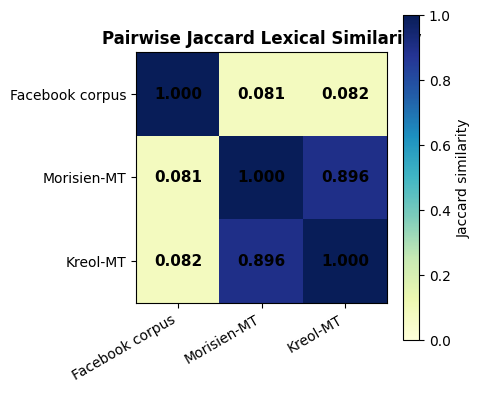

In [57]:
# ============================================================
# JACCARD LEXICAL SIMILARITY ANALYSIS
# Comparing Facebook Corpus, Morisien-MT and Kreol-MT
# ============================================================

# ============================================================
# 1. TEXT NORMALIZATION
# ============================================================

def normalize_text(text):
    """
    Normalize text before lexical analysis.
    """

    if pd.isna(text):
        return ""

    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize(
        "NFKC",
        text
    )

    # Lowercase
    text = text.casefold()

    # Normalize apostrophes
    text = text.replace("’", "'")
    text = text.replace("‘", "'")

    # Remove URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )

    # Remove emails
    text = re.sub(
        r"\S+@\S+\.\S+",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

# ============================================================
# 2. TOKENIZATION
# ============================================================

def tokenize_text(text):
    """
    Extract lexical words.
    """

    text = normalize_text(text)

    tokens = []
    current_word = []

    for index, character in enumerate(text):

        if unicodedata.category(character).startswith("L"):

            current_word.append(character)

        elif (
            character in {"'", "-"}
            and current_word
            and index + 1 < len(text)
            and unicodedata.category(text[index + 1]).startswith("L")
        ):

            current_word.append(character)

        else:

            if current_word:

                token = "".join(
                    current_word
                ).strip("'-")

                if token:
                    tokens.append(token)

                current_word = []


    if current_word:

        token = "".join(
            current_word
        ).strip("'-")

        if token:
            tokens.append(token)


    return tokens

# ============================================================
# 3. CREATE CORPUS VOCABULARY
# ============================================================

def prepare_corpus(
    dataframe,
    text_column
):
    """
    Create vocabulary set from one corpus.
    """

    texts = (
        dataframe[text_column]
        .dropna()
        .astype(str)
        .tolist()
    )

    tokens = []

    for text in texts:

        tokens.extend(
            tokenize_text(text)
        )

    vocabulary = set(tokens)

    return vocabulary

# ============================================================
# 4. JACCARD INDEX
# ============================================================

def calculate_jaccard_similarity(
    vocabulary_a,
    vocabulary_b
):
    """
    Jaccard similarity:

        Intersection / Union
    """

    intersection = (
        vocabulary_a &
        vocabulary_b
    )

    union = (
        vocabulary_a |
        vocabulary_b
    )

    if len(union) == 0:
        return 0

    return len(intersection) / len(union)

# ============================================================
# 5. JACCARD MATRIX
# ============================================================

def calculate_jaccard_matrix(corpora):

    corpus_names = list(
        corpora.keys()
    )

    matrix = pd.DataFrame(
        index=corpus_names,
        columns=corpus_names,
        dtype=float
    )

    for corpus_a in corpus_names:

        for corpus_b in corpus_names:

            matrix.loc[
                corpus_a,
                corpus_b
            ] = calculate_jaccard_similarity(
                corpora[corpus_a],
                corpora[corpus_b]
            )


    return matrix

# ============================================================
# 6. VISUALIZATION
# ============================================================

def plot_jaccard_similarity_matrix(
    similarity_matrix,
    save_path=None
):

    fig, ax = plt.subplots(
        figsize=(4.8, 4.8)
    )

    image = ax.imshow(
        similarity_matrix.values,
        cmap="YlGnBu",
        vmin=0,
        vmax=1
    )

    labels = similarity_matrix.columns

    ax.set_xticks(
        np.arange(len(labels))
    )

    ax.set_yticks(
        np.arange(len(labels))
    )

    ax.set_xticklabels(
        labels,
        fontsize=10
    )

    ax.set_yticklabels(
        labels,
        fontsize=10
    )

    plt.setp(
        ax.get_xticklabels(),
        rotation=30,
        ha="right"
    )

    # Add values inside cells

    for i in range(
        similarity_matrix.shape[0]
    ):

        for j in range(
            similarity_matrix.shape[1]
        ):

            value = similarity_matrix.iloc[
                i,
                j
            ]

            ax.text(
                j,
                i,
                f"{value:.3f}",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold"
            )


    # Colour bar
    cbar = plt.colorbar(
        image,
        shrink=0.8
    )

    cbar.set_label(
        "Jaccard similarity"
    )

    ax.set_title(
        "Pairwise Jaccard Lexical Similarity",
        fontsize=12,
        fontweight="bold"
    )

    plt.tight_layout()
    if save_path:

        plt.savefig(
            save_path,
            dpi=600,
            bbox_inches="tight"
        )


    plt.show()

# ============================================================
# 7. RUN ANALYSIS
# ============================================================

facebook_vocabulary = prepare_corpus(
    mc_joint_text_restoration_df,
    "text"
)

morisien_vocabulary = prepare_corpus(
    morisien_mt_df,
    "target_text"
)

kreol_vocabulary = prepare_corpus(
    kreol_mt_df,
    "src_text"
)

corpora = {

    "Facebook corpus":
        facebook_vocabulary,

    "Morisien-MT":
        morisien_vocabulary,

    "Kreol-MT":
        kreol_vocabulary
}

# Calculate matrix
jaccard_matrix = calculate_jaccard_matrix(
    corpora
)
print(
    "===== JACCARD SIMILARITY MATRIX ====="
)

display(
    jaccard_matrix
)

# Plot
plot_jaccard_similarity_matrix(
    jaccard_matrix,
    save_path=
    "jaccard_similarity_matrix.png"
)

# Export
jaccard_matrix.to_csv(
    "jaccard_similarity_matrix.csv",
    encoding="utf-8-sig"
)

##### ◆◆ Lexical similarity - [2] Shared vocabularies

In [58]:
import pandas as pd
from collections import Counter


# ============================================================
# CREATE CORPUS INFORMATION
# ============================================================

def create_corpus_information(tokens):

    return {
        "vocabulary": set(tokens),
        "frequency": Counter(tokens)
    }


corpora = {

    "Facebook corpus": create_corpus_information(
        facebook_tokens
    ),

    "Morisien-MT": create_corpus_information(
        morisien_tokens
    ),

    "Kreol-MT": create_corpus_information(
        kreol_tokens
    )
}


# ============================================================
# GET VOCABULARIES
# ============================================================

facebook_vocab = corpora["Facebook corpus"]["vocabulary"]
morisien_vocab = corpora["Morisien-MT"]["vocabulary"]
kreol_vocab = corpora["Kreol-MT"]["vocabulary"]


# ============================================================
# 1. SHARED VOCABULARY COUNTS + PERCENTAGES
# ============================================================

shared_vocab_results = []


comparisons = [

    (
        "Morisien-MT ∩ Kreol-MT",
        morisien_vocab,
        kreol_vocab
    ),

    (
        "Facebook corpus ∩ Morisien-MT",
        facebook_vocab,
        morisien_vocab
    ),

    (
        "Facebook corpus ∩ Kreol-MT",
        facebook_vocab,
        kreol_vocab
    )

]


for name, vocab1, vocab2 in comparisons:

    shared = vocab1 & vocab2

    union = vocab1 | vocab2

    percentage = (
        len(shared) / len(union) * 100
    )

    shared_vocab_results.append({

        "Comparison": name,

        "Shared vocabulary size":
            len(shared),

        "Percentage (%)":
            round(percentage, 2)

    })


# All three

all_three_words = (
    facebook_vocab
    &
    morisien_vocab
    &
    kreol_vocab
)


total_union = (
    facebook_vocab
    |
    morisien_vocab
    |
    kreol_vocab
)


shared_vocab_results.append({

    "Comparison":
        "All three corpora",

    "Shared vocabulary size":
        len(all_three_words),

    "Percentage (%)":
        round(
            len(all_three_words)
            /
            len(total_union)
            * 100,
            2
        )

})


shared_vocab_df = pd.DataFrame(
    shared_vocab_results
)


print("===== SHARED VOCABULARY =====")

display(shared_vocab_df)



# ============================================================
# 2. COMMON WORD FREQUENCY TABLE
# ============================================================

frequency_rows = []


for word in all_three_words:

    frequency_rows.append({

        "Word":
            word,

        "Facebook frequency":
            corpora["Facebook corpus"]["frequency"].get(word,0),

        "Morisien-MT frequency":
            corpora["Morisien-MT"]["frequency"].get(word,0),

        "Kreol-MT frequency":
            corpora["Kreol-MT"]["frequency"].get(word,0)

    })


common_words_df = pd.DataFrame(
    frequency_rows
)


common_words_df = (
    common_words_df
    .sort_values(
        by="Facebook frequency",
        ascending=False
    )
)


print(
    "Number of words shared by all three:",
    len(all_three_words)
)


print("===== COMMON MC VOCABULARY =====")

display(
    common_words_df.head(10)
)


# ============================================================
# 3. FACEBOOK-ONLY VOCABULARY
# ============================================================


formal_vocab = (
    morisien_vocab
    |
    kreol_vocab
)


facebook_only_words = (
    facebook_vocab
    -
    formal_vocab
)


facebook_only_df = pd.DataFrame({

    "Word":
        sorted(facebook_only_words)

})


print("===== FACEBOOK-ONLY VOCABULARY =====")

display(
    facebook_only_df.head(10)
)

===== SHARED VOCABULARY =====


,Comparison,Shared vocabulary size,Percentage (%)
0,Morisien-MT ∩ Kreol-MT,1764,6.23
1,Facebook corpus ∩ Morisien-MT,2788,9.68
2,Facebook corpus ∩ Kreol-MT,2490,8.55
3,All three corpora,772,1.91


Number of words shared by all three: 772
===== COMMON MC VOCABULARY =====


,Word,Facebook frequency,Morisien-MT frequency,Kreol-MT frequency
758,la,9538,7,1571
661,li,4802,2,3036
309,ki,4347,3,3194
321,ti,2515,1,4448
379,to,1982,3751,234
563,pu,1951,18,1402
694,so,1839,323,943
402,dan,1649,1,2064
276,et,1621,2,9
257,1,1482,26,21


===== FACEBOOK-ONLY VOCABULARY =====


,Word
0,0000000etoile
1,0000030
2,000km
3,000mile
4,01
5,06
6,0645am
7,09
8,0nly
9,0u


##### ◆◆ Lexical diversity - [1] Vocabulary size [2] Hapax legomena

In [59]:
from collections import Counter
import pandas as pd

def prepare_corpus(texts):
    """
    Prepare corpus with tokens, frequency and vocabulary.
    """

    tokens = []

    for text in texts:
        tokens.extend(
            tokenize_text(text)
        )

    return {
        "tokens": tokens,
        "frequency": Counter(tokens),
        "vocabulary": set(tokens)
    }
corpora = {

    "Facebook corpus": prepare_corpus(
        mc_joint_text_restoration_df["text"]
    ),

    "Morisien-MT": prepare_corpus(
        morisien_mt_df["target_text"]
    ),

    "Kreol-MT": prepare_corpus(
        kreol_mt_df["src_text"]
    )
}

def calculate_hapax_summary(corpora):

    results = []

    for corpus_name, corpus in corpora.items():

        frequency = corpus["frequency"]
        vocabulary = corpus["vocabulary"]
        tokens = corpus["tokens"]

        hapax_words = {
            word
            for word, count in frequency.items()
            if count == 1
        }

        vocabulary_size = len(vocabulary)
        total_tokens = len(tokens)

        hapax_percentage = (
            len(hapax_words) /
            vocabulary_size * 100
            if vocabulary_size > 0
            else 0
        )

        results.append({

            "Corpus": corpus_name,

            "Total tokens": total_tokens,

            "Vocabulary size": vocabulary_size,

            "Hapax count": len(hapax_words),

            "Hapax percentage (%)": round(
                hapax_percentage,
                2
            )
        })

    return pd.DataFrame(results)

hapax_df = calculate_hapax_summary(corpora)

display(hapax_df)

,Corpus,Total tokens,Vocabulary size,Hapax count,Hapax percentage (%)
0,Facebook corpus,239358,16109,4156,25.80
1,Morisien-MT,125556,16822,10845,64.47
2,Kreol-MT,110719,15477,9905,64.00


##### ◆◆ Lexical diversity - [3] MATTR

In [60]:
def tokenize_corpus(text_series):
    """
    Convert a corpus into a list of word tokens.
    """

    tokens = []

    for text in text_series.dropna():

        text = str(text).lower()

        words = re.findall(r"\b[\w']+\b", text)

        tokens.extend(words)

    return tokens

def calculate_mattr(tokens, window_size=500):
    """
    Calculate Moving Average Type-Token Ratio (MATTR).

    Args:
        tokens:
            List of word tokens

        window_size:
            Number of words per moving window

    Returns:
        MATTR score
    """

    if len(tokens) < window_size:
        return len(set(tokens)) / len(tokens)


    ttr_scores = []

    for i in range(len(tokens) - window_size + 1):

        window = tokens[i:i + window_size]

        types = len(set(window))

        tokens_count = len(window)

        ttr = types / tokens_count

        ttr_scores.append(ttr)


    return np.mean(ttr_scores)

facebook_tokens = tokenize_corpus(
    mc_joint_text_restoration_df["text"]
)

morisien_tokens = tokenize_corpus(
    morisien_mt_df["source_text"]
)

kreol_tokens = tokenize_corpus(
    kreol_mt_df["src_text"]
)

mattr_results = pd.DataFrame({

    "Corpus": [
        "Facebook",
        "MorisienMT",
        "KreolMT"
    ],

    "Total tokens": [
        len(facebook_tokens),
        len(morisien_tokens),
        len(kreol_tokens)
    ],

    "Unique words": [
        len(set(facebook_tokens)),
        len(set(morisien_tokens)),
        len(set(kreol_tokens))
    ],

    "MATTR": [
        calculate_mattr(facebook_tokens),
        calculate_mattr(morisien_tokens),
        calculate_mattr(kreol_tokens)
    ]

})

mattr_results

,Corpus,Total tokens,Unique words,MATTR
0,Facebook,243444,16563,0.603197
1,MorisienMT,143127,15017,0.516977
2,KreolMT,112588,15041,0.603084


#### ◆ Orthographic variations analysis

##### ◆◆ Orthographic variation - [1] Diacritical analysis

In [61]:
def tokenize_for_diacritics(text):
    """
    Extract words while preserving accented characters.
    """

    if pd.isna(text):
        return []

    text = str(text).lower()

    # Keep letters including accented Unicode characters
    words = re.findall(
        r"[a-zàâçéèêëîïôûùü]+",
        text
    )

    return words

def get_diacritical_words(
    dataframe,
    text_column
):
    """
    Find words containing diacritical marks.

    Returns:
        word frequencies
    """

    counter = Counter()

    for text in dataframe[text_column]:

        words = tokenize_for_diacritics(text)

        for word in words:

            # Check if word contains accented character
            if re.search(
                r"[àâçéèêëîïôûùü]",
                word
            ):
                counter[word] += 1

    return counter

def diacritical_summary(
    dataframe,
    text_column,
    corpus_name
):
    """
    Create summary statistics.
    """

    diacritical_words = get_diacritical_words(
        dataframe,
        text_column
    )

    total_words = sum(diacritical_words.values())

    return pd.DataFrame([
        {
            "Corpus": corpus_name,
            "Number of diacritical word types":
                len(diacritical_words),

            "Number of diacritical word occurrences":
                total_words,

            "Most frequent examples":
                ", ".join(
                    [
                        f"{word} ({count})"
                        for word, count
                        in diacritical_words.most_common(10)
                    ]
                )
        }
    ])

In [62]:
def diacritical_word_table(
    dataframe,
    text_column,
    corpus_name,
    top_n=30
):
    """
    Return the most frequent words containing diacritics.
    """

    words = get_diacritical_words(
        dataframe,
        text_column
    )

    results = []

    for word, frequency in words.most_common(top_n):

        results.append({
            "Corpus": corpus_name,
            "Word": word,
            "Frequency": frequency
        })

    return pd.DataFrame(results)

def diacritical_summary_with_counts(
    dataframe,
    text_column,
    corpus_name
):

    words = get_diacritical_words(
        dataframe,
        text_column
    )

    return pd.DataFrame([
        {
            "Corpus": corpus_name,
            "Diacritical word types": len(words),
            "Diacritical word occurrences": sum(words.values())
        }
    ])

In [63]:
facebook_diacritical_words = diacritical_word_table(
    mc_joint_text_restoration_df,
    "text",
    "Facebook corpus",
    top_n=1402
)

morisien_diacritical_words = diacritical_word_table(
    morisien_mt_df,
    "target_text",
    "Morisien-MT",
    top_n=30
)

kreol_diacritical_words = diacritical_word_table(
    kreol_mt_df,
    "src_text",
    "Kreol-MT",
    top_n=30
)

display(facebook_diacritical_words)
display(morisien_diacritical_words)
display(kreol_diacritical_words)

diacritical_summary = pd.concat(
    [
        diacritical_summary_with_counts(
            mc_joint_text_restoration_df,
            "text",
            "Facebook corpus"
        ),

        diacritical_summary_with_counts(
            morisien_mt_df,
            "target_text",
            "Morisien-MT"
        ),

        diacritical_summary_with_counts(
            kreol_mt_df,
            "src_text",
            "Kreol-MT"
        )
    ],
    ignore_index=True
)

display(diacritical_summary)

facebook_diacritical_words.to_csv(
    "facebook_diacritical_words.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Facebook diacritical words saved.")

,Corpus,Word,Frequency
0,Facebook corpus,à,204
1,Facebook corpus,même,152
2,Facebook corpus,ça,120
3,Facebook corpus,après,114
4,Facebook corpus,là,86
...,...,...,...
1397,Facebook corpus,trimé,1
1398,Facebook corpus,dépasse,1
1399,Facebook corpus,loué,1
1400,Facebook corpus,prémié,1


,Corpus,Word,Frequency
0,Morisien-MT,santé,7
1,Morisien-MT,prêt,2
2,Morisien-MT,mée,2
3,Morisien-MT,émigré,1
4,Morisien-MT,passé,1
5,Morisien-MT,arête,1
6,Morisien-MT,josé,1
7,Morisien-MT,bové,1
8,Morisien-MT,bérenger,1
9,Morisien-MT,chaussée,1


,Corpus,Word,Frequency
0,Kreol-MT,santé,6
1,Kreol-MT,én,2
2,Kreol-MT,mée,2
3,Kreol-MT,invité,1
4,Kreol-MT,lanivérser,1
5,Kreol-MT,émigré,1
6,Kreol-MT,léléktora,1
7,Kreol-MT,fér,1
8,Kreol-MT,passé,1
9,Kreol-MT,géj,1


,Corpus,Diacritical word types,Diacritical word occurrences
0,Facebook corpus,1402,5950
1,Morisien-MT,13,21
2,Kreol-MT,18,25


Facebook diacritical words saved.


##### ◆◆ Orthographic variation - [2] Character repetition

In [64]:
def normalize_text(text):
    """
    Basic text cleaning while preserving repeated letters.
    """

    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Keep letters, apostrophes and spaces
    text = re.sub(r"[^a-zàâçéèêëîïôûùü\s']", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


def tokenize(text):
    """
    Split cleaned text into words.
    """

    return normalize_text(text).split()

# ============================================================
# WORD FREQUENCIES
# ============================================================

def get_word_frequency(
    dataframe,
    text_column
):
    """
    Count the frequency of every word in a corpus.
    """

    counter = Counter()

    for text in dataframe[text_column]:
        counter.update(tokenize(text))

    return counter

# ============================================================
# DETECT CHARACTER REPETITION
# ============================================================

def has_repeated_letters(word):
    """
    Detect words containing a character repeated
    three or more consecutive times.

    Examples:
        laaa
        merciii
        pffff
        etaaaa
    """

    return bool(
        re.search(
            r"(.)\1{2,}",
            word
        )
    )


def get_repeated_letter_words(
    dataframe,
    text_column
):
    """
    Return all repeated-letter words with their frequencies.
    """

    frequency = get_word_frequency(
        dataframe,
        text_column
    )

    repeated = Counter()

    for word, count in frequency.items():

        if has_repeated_letters(word):

            repeated[word] = count

    return repeated

# ============================================================
# SUMMARY TABLE
# ============================================================

def repeated_letter_summary(
    dataframe,
    text_column,
    corpus_name
):
    """
    Produce summary statistics for repeated-letter words.
    """

    frequency = get_word_frequency(
        dataframe,
        text_column
    )

    repeated = get_repeated_letter_words(
        dataframe,
        text_column
    )

    total_word_types = len(frequency)
    total_word_occurrences = sum(frequency.values())

    repeated_types = len(repeated)
    repeated_occurrences = sum(repeated.values())

    percentage = (
        repeated_occurrences /
        total_word_occurrences * 100
    ) if total_word_occurrences else 0

    return pd.DataFrame([{

        "Corpus": corpus_name,

        "Repeated word types":
            repeated_types,

        "Repeated word occurrences":
            repeated_occurrences,

        "Percentage of all word occurrences":
            round(
                percentage,
                3
            )

    }])


# ============================================================
# MOST FREQUENT REPEATED WORDS
# ============================================================

def repeated_letter_table(
    dataframe,
    text_column,
    corpus_name,
    top_n=20
):
    """
    Return the most frequent repeated-letter words.
    """

    repeated = get_repeated_letter_words(
        dataframe,
        text_column
    )

    results = []

    for word, frequency in repeated.most_common(top_n):

        results.append({

            "Corpus": corpus_name,
            "Word": word,
            "Occurrences": frequency

        })

    return pd.DataFrame(results)

repeated_summary = pd.concat([

    repeated_letter_summary(
        mc_joint_text_restoration_df,
        "text",
        "Facebook corpus"
    ),

    repeated_letter_summary(
        morisien_mt_df,
        "target_text",
        "Morisien-MT"
    ),

    repeated_letter_summary(
        kreol_mt_df,
        "src_text",
        "Kreol-MT"
    )

], ignore_index=True)

display(repeated_summary)

,Corpus,Repeated word types,Repeated word occurrences,Percentage of all word occurrences
0,Facebook corpus,322,638,0.266
1,Morisien-MT,11,39,0.031
2,Kreol-MT,10,31,0.028


In [65]:
# ============================================================
# COMBINED EXAMPLES TABLE
# ============================================================

repeated_examples = pd.concat(
    [
        repeated_letter_table(
            mc_joint_text_restoration_df,
            "text",
            "Facebook corpus",
            top_n=10
        ),
        repeated_letter_table(
            morisien_mt_df,
            "target_text",
            "Morisien-MT",
            top_n=10
        ),
        repeated_letter_table(
            kreol_mt_df,
            "src_text",
            "Kreol-MT",
            top_n=10
        )
    ],
    ignore_index=True
)

display(repeated_examples)

,Corpus,Word,Occurrences
0,Facebook corpus,mmm,34
1,Facebook corpus,laaa,21
2,Facebook corpus,saaa,18
3,Facebook corpus,tiouuu,16
4,Facebook corpus,taaa,11
5,Facebook corpus,pfff,10
6,Facebook corpus,laaaa,9
7,Facebook corpus,ahhh,8
8,Facebook corpus,dooo,7
9,Facebook corpus,oufff,7


##### ◆◆ Orthographic variation - [2] Word reduplication

In [66]:
def normalize_text(text):
    """
    Clean text while preserving hyphens.
    """

    if pd.isna(text):
        return ""

    text = str(text).lower()

    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    text = re.sub(r"[^a-zàâçéèêëîïôûùü\s'-]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text


def find_reduplication(text):
    """
    Detect:
        plore plore
        vite vite
        plore-plore
        vite-vite
    """

    text = normalize_text(text)

    found = []

    # space-separated
    pattern_space = r"\b([a-zàâçéèêëîïôûùü']+)\s+\1\b"

    # hyphen-separated
    pattern_hyphen = r"\b([a-zàâçéèêëîïôûùü']+)-\1\b"

    found.extend(re.findall(pattern_space, text))
    found.extend(re.findall(pattern_hyphen, text))

    return found


def reduplication_counter(
    dataframe,
    text_column
):
    """
    Count reduplicated words.
    """

    counter = Counter()

    for text in dataframe[text_column]:

        words = find_reduplication(text)

        counter.update(words)

    return counter

def reduplication_summary(
    dataframe,
    text_column,
    corpus_name
):

    counter = reduplication_counter(
        dataframe,
        text_column
    )

    return pd.DataFrame([{

        "Corpus": corpus_name,
        "Reduplicated word types": len(counter),
        "Reduplicated occurrences": sum(counter.values())

    }])

In [67]:
def reduplication_table(
    dataframe,
    text_column,
    corpus_name,
    top_n=20
):

    counter = reduplication_counter(
        dataframe,
        text_column
    )

    rows = []

    for word, count in counter.most_common(top_n):

        rows.append({

            "Corpus": corpus_name,
            "Word": word,
            "Occurrences": count

        })

    return pd.DataFrame(rows)

reduplication_summary_df = pd.concat([

    reduplication_summary(
        mc_joint_text_restoration_df,
        "text",
        "Facebook corpus"
    ),

    reduplication_summary(
        morisien_mt_df,
        "target_text",
        "Morisien-MT"
    ),

    reduplication_summary(
        kreol_mt_df,
        "src_text",
        "Kreol-MT"
    )

], ignore_index=True)

display(reduplication_summary_df)

,Corpus,Reduplicated word types,Reduplicated occurrences
0,Facebook corpus,163,618
1,Morisien-MT,158,319
2,Kreol-MT,155,281


In [68]:
def reduplication_examples(
    dataframe,
    text_column,
    corpus_name,
    top_n=30
):
    """
    Return examples of reduplicated words/forms with frequencies.
    Detects:
        vite vite
        vite-vite
    """

    counter = Counter()

    for text in dataframe[text_column]:

        text = normalize_text(text)

        # space-separated reduplication
        space_matches = re.findall(
            r"\b([a-zàâçéèêëîïôûùü']+)\s+\1\b",
            text
        )

        # hyphen-separated reduplication
        hyphen_matches = re.findall(
            r"\b([a-zàâçéèêëîïôûùü']+)-\1\b",
            text
        )

        # keep original display form
        for word in space_matches:
            counter[f"{word} {word}"] += 1

        for word in hyphen_matches:
            counter[f"{word}-{word}"] += 1


    results = []

    for form, count in counter.most_common(top_n):

        results.append({

            "Corpus": corpus_name,
            "Reduplicated form": form,
            "Occurrences": count

        })

    return pd.DataFrame(results)

In [69]:
facebook_redup_examples = reduplication_examples(
    mc_joint_text_restoration_df,
    "text",
    "Facebook corpus",
    top_n=20
)


morisien_redup_examples = reduplication_examples(
    morisien_mt_df,
    "target_text",
    "Morisien-MT",
    top_n=20
)


kreol_redup_examples = reduplication_examples(
    kreol_mt_df,
    "src_text",
    "Kreol-MT",
    top_n=20
)


display(facebook_redup_examples)
display(morisien_redup_examples)
display(kreol_redup_examples)

,Corpus,Reduplicated form,Occurrences
0,Facebook corpus,li li,54
1,Facebook corpus,la la,46
2,Facebook corpus,zot zot,37
3,Facebook corpus,bel bel,30
4,Facebook corpus,bla bla,22
5,Facebook corpus,sa sa,22
6,Facebook corpus,ou ou,18
7,Facebook corpus,name name,17
8,Facebook corpus,bien bien,17
9,Facebook corpus,vite vite,13


,Corpus,Reduplicated form,Occurrences
0,Morisien-MT,li li,30
1,Morisien-MT,zot zot,12
2,Morisien-MT,for-for,12
3,Morisien-MT,sinn sinn,9
4,Morisien-MT,byen byen,8
5,Morisien-MT,divan-divan,8
6,Morisien-MT,dousma-dousma,5
7,Morisien-MT,but-but,5
8,Morisien-MT,but but,5
9,Morisien-MT,lerwa lerwa,5


,Corpus,Reduplicated form,Occurrences
0,Kreol-MT,li li,28
1,Kreol-MT,zot zot,10
2,Kreol-MT,for-for,10
3,Kreol-MT,sinn sinn,7
4,Kreol-MT,byen byen,7
5,Kreol-MT,divan-divan,6
6,Kreol-MT,but-but,5
7,Kreol-MT,nu nu,5
8,Kreol-MT,u u,5
9,Kreol-MT,lerwa lerwa,4


##### ◆◆ Punctuation distribution analysis

In [70]:
import re
import pandas as pd
from collections import Counter


def get_punctuation_sequences(
    dataframe,
    text_column
):
    """
    Extract punctuation sequences:
    Examples:
    ...
    !!!
    ??
    ?!
    .....
    """

    counter = Counter()

    for text in dataframe[text_column]:

        if pd.isna(text):
            continue

        text = str(text)

        # Find consecutive punctuation marks
        sequences = re.findall(
            r"[.!?,;:]{2,}",
            text
        )

        counter.update(sequences)

    return counter


def punctuation_sequence_table(
    dataframe,
    text_column,
    corpus_name,
    top_n=20
):

    sequences = get_punctuation_sequences(
        dataframe,
        text_column
    )

    results = []

    for seq, count in sequences.most_common(top_n):

        results.append({

            "Corpus": corpus_name,
            "Punctuation sequence": seq,
            "Occurrences": count

        })

    return pd.DataFrame(results)

In [71]:
facebook_punct_seq = punctuation_sequence_table(
    mc_joint_text_restoration_df,
    "text",
    "Facebook corpus"
)


morisien_punct_seq = punctuation_sequence_table(
    morisien_mt_df,
    "target_text",
    "Morisien-MT"
)


kreol_punct_seq = punctuation_sequence_table(
    kreol_mt_df,
    "src_text",
    "Kreol-MT"
)


display(facebook_punct_seq)
display(morisien_punct_seq)
display(kreol_punct_seq)

,Corpus,Punctuation sequence,Occurrences
0,Facebook corpus,..,1431
1,Facebook corpus,...,1038
2,Facebook corpus,....,306
3,Facebook corpus,??,176
4,Facebook corpus,???,125
5,Facebook corpus,.....,100
6,Facebook corpus,!!,88
7,Facebook corpus,!!!,80
8,Facebook corpus,",,",46
9,Facebook corpus,......,36


,Corpus,Punctuation sequence,Occurrences
0,Morisien-MT,...,65
1,Morisien-MT,..,3
2,Morisien-MT,!.,2
3,Morisien-MT,?.,1
4,Morisien-MT,....,1
5,Morisien-MT,"?,",1


,Corpus,Punctuation sequence,Occurrences
0,Kreol-MT,...,63
1,Kreol-MT,..,3
2,Kreol-MT,!.,1
